<a href="https://colab.research.google.com/github/Ritapaz/redes-neurais/blob/main/Minicurso_redes_neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


In [ ]:
np.random.seed(42)

In [ ]:
tf.random.set_seed(42)

In [ ]:
df = pd.read_csv("base_simulada_consumo_temporal.csv", parse_dates=["data"],)

In [ ]:
df = df.sort_values("data")

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.head()

,data,renda_mensal_reais,taxa_juros_anual_pct,inflacao_anual_pct,desemprego_pct,consumo_mensal_reais
0,1943-05-01,2200.00,9.00,4.50,9.50,705.05
1,1943-06-01,2170.20,9.14,4.78,9.81,846.46
2,1943-07-01,2341.12,9.44,5.38,10.43,910.02
3,1943-08-01,2485.09,10.20,5.73,10.15,1320.63
4,1943-09-01,2224.64,10.61,5.28,10.20,1228.63


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data                  1000 non-null   datetime64[ns]
 1   renda_mensal_reais    1000 non-null   float64       
 2   taxa_juros_anual_pct  1000 non-null   float64       
 3   inflacao_anual_pct    1000 non-null   float64       
 4   desemprego_pct        1000 non-null   float64       
 5   consumo_mensal_reais  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 47.0 KB


In [ ]:
df.describe().round(2)

,data,renda_mensal_reais,taxa_juros_anual_pct,inflacao_anual_pct,desemprego_pct,consumo_mensal_reais
count,1000,1000.00,1000.00,1000.00,1000.00,1000.00
mean,1984-12-15 16:59:31.200000,4648.48,8.64,4.57,8.78,2372.32
min,1943-05-01 00:00:00,1728.98,2.37,1.56,5.19,400.00
25%,1964-02-22 18:00:00,3474.05,6.59,3.62,7.66,1591.52
50%,1984-12-16 12:00:00,4638.84,8.57,4.50,8.63,2283.36
75%,2005-10-08 18:00:00,5859.69,10.71,5.48,10.07,3189.11
max,2026-08-01 00:00:00,7866.50,14.03,7.94,12.00,4739.99
std,NaN,1467.65,2.59,1.26,1.52,1061.08


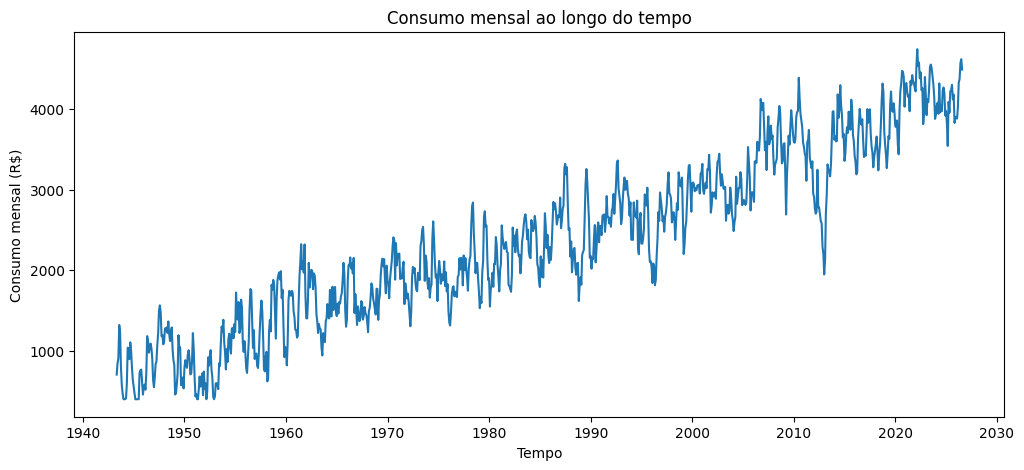

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    df["data"],
    df["consumo_mensal_reais"],
)
plt.xlabel("Tempo")
plt.ylabel("Consumo mensal (R$)")
plt.title("Consumo mensal ao longo do tempo")
plt.show()

In [ ]:
X = df[["renda_mensal_reais","taxa_juros_anual_pct","inflacao_anual_pct","desemprego_pct",]]
y = df["consumo_mensal_reais"]

In [ ]:
datas = df["data"]

In [ ]:
corte = int(len(df) * 0.80)
X_train = X.iloc[:corte]
y_train = y.iloc[:corte]
datas_train = datas.iloc[:corte]
X_test = X.iloc[corte:]
y_test = y.iloc[corte:]
datas_test = datas.iloc[corte:]

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
corte_validacao = int(len(X_train_scaled) * 0.80)
X_fit = X_train_scaled[:corte_validacao]
y_fit = y_train.iloc[:corte_validacao].to_numpy()
X_val = X_train_scaled[corte_validacao:]
y_val = y_train.iloc[corte_validacao:].to_numpy()

In [ ]:
model = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(8, activation="relu"),
    Dense(1),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,loss="mse")

In [ ]:
history = model.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    shuffle=False,
    verbose=0,
)

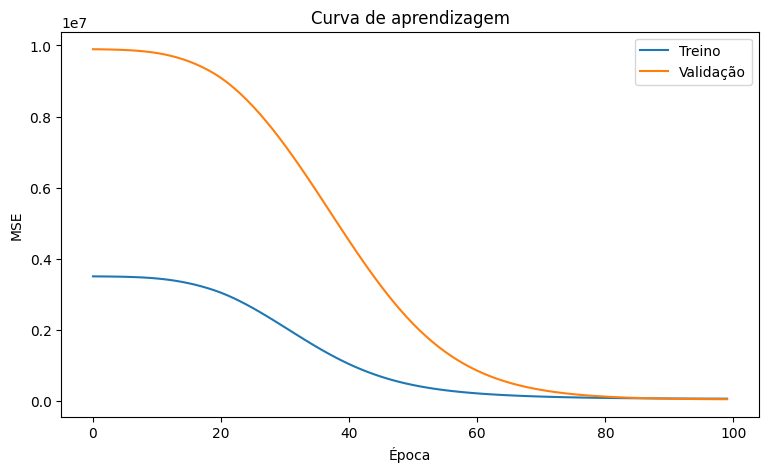

In [ ]:
loss_treino = history.history["loss"]
loss_validacao = history.history["val_loss"]
plt.figure(figsize=(9, 5))
plt.plot(
    loss_treino,
    label="Treino",
)
plt.plot(
    loss_validacao,
    label="Validação",
)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de aprendizagem")
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test_scaled,verbose=0)
y_pred = y_pred.flatten()

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

In [ ]:
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

MAE: 196.06
RMSE: 254.29
R²: 0.7462


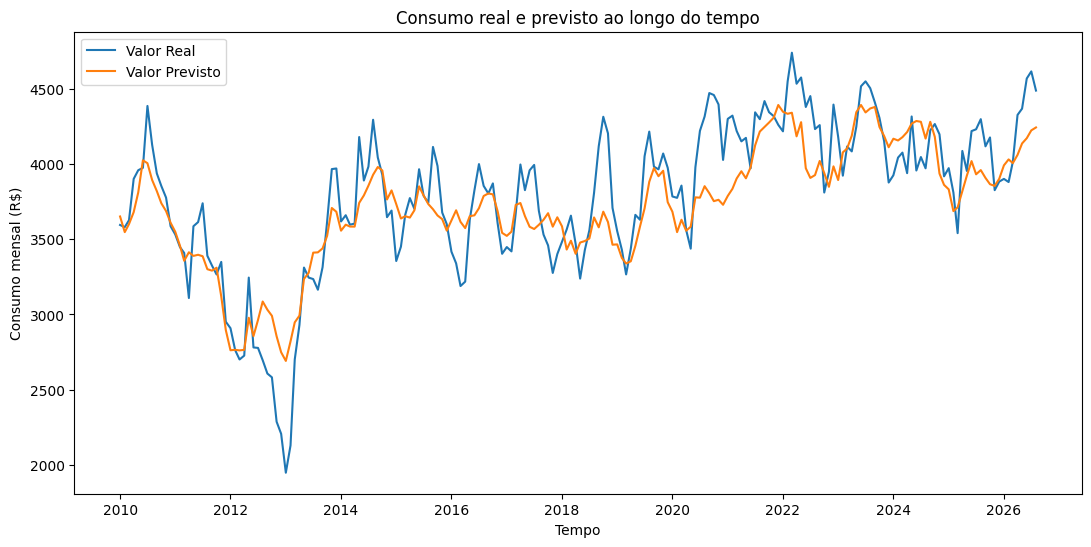

In [ ]:
plt.figure(figsize=(13, 6))
plt.plot(datas_test,y_test.to_numpy(),label="Valor Real")
plt.plot(datas_test,y_pred,label="Valor Previsto")
plt.xlabel("Tempo")
plt.ylabel("Consumo mensal (R$)")
plt.title("Consumo real e previsto ao longo do tempo")
plt.legend()
plt.show()


In [ ]:
residuos = y_test.to_numpy() - y_pred

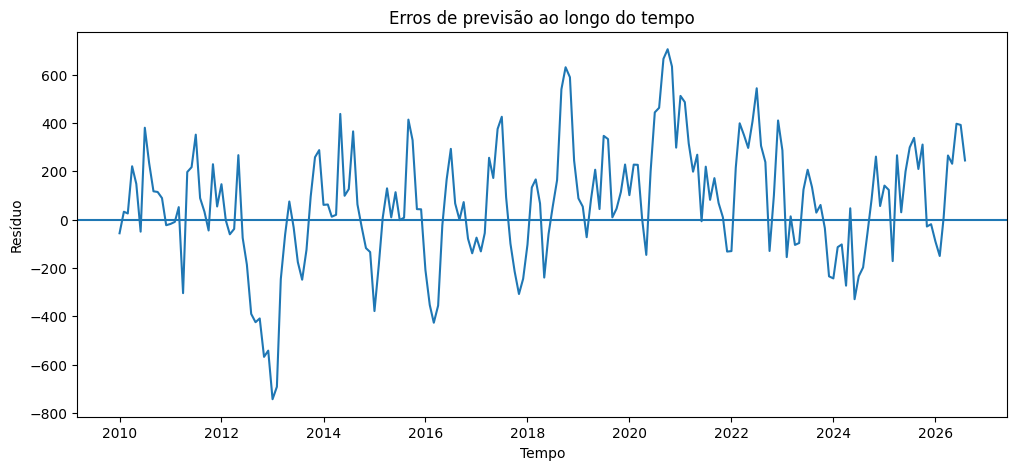

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(datas_test,residuos)
plt.axhline(0)
plt.xlabel("Tempo")
plt.ylabel("Resíduo")
plt.title("Erros de previsão ao longo do tempo")
plt.show()